# Lagrangian Training (GMM + CVaR)

Standalone notebook mirroring the domain-randomization Lagrangian setup with the same PB cost modes.

In [5]:
import copy
import itertools
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from performance_boosting import PBClosedLoop
from ren import ContractiveREN
from robot import RobotPlant, ProportionalController, StabilizedRobot
from plot_functions import plot_pb_trajectories
from dataset import generate_random_batch
from losses_and_wrappers import PBLoss, HardConstraintCVaRLossWrapper

## Simulation and loss parameters

In [6]:
# setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# seed
seed = 1
torch.manual_seed(seed)
np.random.seed(seed)

# dataset parameters (GMM)
gmm = True
gaussian = not gmm
if gaussian:
    x0_centers = [[-1.0, -1.0]]
    x0_stds = [0.2]
    x0_probs = None
elif gmm:
    x0_centers = [
        [-1.0, -1.0],
        [1.0, -1.0],
        [1.0, 1.5],
    ]
    x0_stds = [0.2, 0.1, 0.4]
    x0_probs = [0.6, 0.2, 0.2]

noise_std = 0.02

# controller / dynamics parameters
kp = 0.5
n_agents = 1
state_dim = 4
input_dim = 2
dt = 0.05

b_nom = 1.0
m_nom = 1.0
b2_nom = 0.2

b_sim = 1.0
m_sim = 1.0
b2_sim = 0.2

# REN parameters (augmented capacity)
initialization_std = 0.08
dim_internal = 4
dim_nl = 4

# loss matrices
lambda_x = 1.0
Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * lambda_x
Q = torch.kron(torch.eye(n_agents), Q_agent)

lambda_u = 0.01
R_agent = torch.eye(2) * lambda_u
R = torch.kron(torch.eye(n_agents), R_agent)

# obstacle and cost configuration
lambda_obs = 100.0
track_mode = "quadratic"
coll_mode = "squared_hinge"

obs_centers = [torch.tensor([0.5, -0.5])]
obs_radii = [[1.0, 0.15]]
obs_radii_safe = [[r + 0.05 for r in obs] for obs in obs_radii]

x_target = torch.zeros(4 * n_agents)

# finite-sample correction settings for quantile training
conditional_training = False
delta = 0.01
m_cert = 2000

# training budget
num_training_steps = 2000
log_interval = 5
batch_size = 256
horizon = 500
max_grad_norm = 5.0

# tuned optimizer dynamics
lr_primal = 1e-3
lr_dual = 3e-4
min_lr_primal = 1e-4
min_lr_dual = 5e-5
lr_plateau_factor = 0.5
lr_plateau_patience = 8
lr_plateau_threshold = 1e-4
primal_weight_decay = 1e-5
dual_warmup_steps = 120
dual_step_interval_stage1 = 2
dual_step_interval_stage2 = 1

# staged optimization settings
stage1_fraction = 0.35

# quantile-constrained target and stage-1 relaxation
alpha_true = 0.05
alpha_true_stage1 = 0.2
tau_safe_bar = 1e-4
tau_safe_bar_stage1 = 5e-4

# expected-constraint target and stage-1 relaxation
tau_safe_bar_exp_final = 1e-4
tau_safe_bar_exp_stage1 = 5e-4

# early stopping
early_stop_patience = 50
early_stop_min_delta = 1e-4
checkpoint_path = "ren_lagrangian_optimized_checkpoint.pt"
checkpoint_path_exp = "ren_expected_constraint_optimized_checkpoint.pt"

# validation / testing sizes
num_val_samples = 400
num_test_samples = 10000
num_test_samples_exp = 10000

## Build plants, controller, and fixed validation set

In [7]:
# Nominal and simulation plants
sys_nom = RobotPlant(b=b_nom, b2=b2_nom, m=m_nom, n_agents=n_agents).to(device)
sys_sim = RobotPlant(b=b_sim, b2=b2_sim, m=m_sim, n_agents=n_agents).to(device)

ctl = ProportionalController(kp=kp, n_agents=n_agents).to(device)
f_nom = StabilizedRobot(sys_nom, ctl).to(device)
f_sim = StabilizedRobot(sys_sim, ctl).to(device)

for p in f_nom.parameters():
    p.requires_grad_(False)
for p in f_sim.parameters():
    p.requires_grad_(False)

fixed_val_w = generate_random_batch(
    batch_size=num_val_samples,
    horizon=horizon,
    n_agents=n_agents,
    x0_centers=x0_centers,
    x0_stds=x0_stds,
    x0_probs=x0_probs,
    noise_std=noise_std,
    device=device,
)

## Lagrangian model and training loop

In [8]:
# REN + PB closed loop (augmented model)
ren_lagrangian = ContractiveREN(
    dim_in=state_dim * n_agents,
    dim_out=input_dim * n_agents,
    dim_internal=dim_internal,
    dim_nl=dim_nl,
    initialization_std=initialization_std,
).to(device)

PB_closed_loop_sim_lagrangian = PBClosedLoop(ren_lagrangian, f_sim, f_nom).to(device)

metric = PBLoss(
    x_target, Q, R, lambda_obs, obs_centers,
    obs_radii_safe=obs_radii_safe,
    n_agents=n_agents,
    track_mode=track_mode,
    coll_mode=coll_mode,
).to(device)

# build wrapper once, alpha will be updated per stage
epsilon_cert = np.sqrt(np.log(2 / delta) / (2 * m_cert)) if conditional_training else 0.0
alpha_train_stage1 = max(alpha_true_stage1 - epsilon_cert, 1e-6)
alpha_train_stage2 = max(alpha_true - epsilon_cert, 1e-6)

loss_wrapper = HardConstraintCVaRLossWrapper(
    alpha=alpha_train_stage1,
    tau_safe_bar=tau_safe_bar_stage1,
    metric=metric,
).to(device)

primal_params = list(PB_closed_loop_sim_lagrangian.parameters()) + [loss_wrapper.tau]
opt_primal = torch.optim.AdamW(
    primal_params,
    lr=lr_primal,
    betas=(0.9, 0.99),
    weight_decay=primal_weight_decay,
    amsgrad=True,
)
opt_dual = torch.optim.Adam(
    [loss_wrapper.pre_lambda],
    lr=lr_dual,
    betas=(0.9, 0.99),
    maximize=True,
    amsgrad=True,
)

sched_primal = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_primal, mode="min", factor=lr_plateau_factor, patience=lr_plateau_patience,
    threshold=lr_plateau_threshold, min_lr=min_lr_primal
)
sched_dual = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_dual, mode="min", factor=lr_plateau_factor, patience=lr_plateau_patience,
    threshold=lr_plateau_threshold, min_lr=min_lr_dual
)

train_lagrangians = []
val_lagrangians = []
val_perfs = []
val_cvars = []
val_lambdas = []

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

best_val_lagrangian = float("inf")
num_bad_val_steps = 0
stage1_steps = int(stage1_fraction * num_training_steps)
stage2_initialized = False

print(f"Starting optimized Lagrangian training on {device}...")
pbar = tqdm(range(num_training_steps), desc="Hard Constrained Optimized")

for step in pbar:
    is_stage1 = step < stage1_steps
    current_alpha_train = alpha_train_stage1 if is_stage1 else alpha_train_stage2
    current_tau_safe_bar = tau_safe_bar_stage1 if is_stage1 else tau_safe_bar

    if (not is_stage1) and (not stage2_initialized):
        stage2_initialized = True
        best_val_lagrangian = float("inf")
        num_bad_val_steps = 0
        print("Entering Stage 2: early stopping and checkpoint selection now use real alpha/tau targets.")

    loss_wrapper.alpha = current_alpha_train
    loss_wrapper.tau_safe_bar = current_tau_safe_bar

    dual_step_interval = dual_step_interval_stage1 if is_stage1 else dual_step_interval_stage2

    PB_closed_loop_sim_lagrangian.train()
    opt_primal.zero_grad(set_to_none=True)
    opt_dual.zero_grad(set_to_none=True)

    batch_w = generate_random_batch(
        batch_size=batch_size,
        horizon=horizon,
        n_agents=n_agents,
        x0_centers=x0_centers,
        x0_stds=x0_stds,
        x0_probs=x0_probs,
        noise_std=noise_std,
        device=device,
    )

    traj_x_train, traj_u_train, _ = PB_closed_loop_sim_lagrangian.run(batch_w)
    lagrangian, _, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)

    lagrangian.backward()
    torch.nn.utils.clip_grad_norm_(PB_closed_loop_sim_lagrangian.parameters(), max_grad_norm)
    opt_primal.step()

    should_update_dual = (step >= dual_warmup_steps) and ((step + 1) % dual_step_interval == 0)
    if should_update_dual:
        torch.nn.utils.clip_grad_norm_([loss_wrapper.pre_lambda], 1.0)
        opt_dual.step()
        with torch.no_grad():
            loss_wrapper.pre_lambda.clamp_(-8.0, 8.0)

    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_lagrangian.eval()
        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_lagrangian.run(fixed_val_w)
            val_lag, val_perf, val_cvar, val_lam, val_viol = loss_wrapper(traj_x_val, traj_u_val)

        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

        val_lag_item = val_lag.item()
        val_perf_item = val_perf.item()
        val_cvar_item = val_cvar.item()
        val_lam_item = val_lam.item()
        val_viol_item = val_viol.item()

        train_lagrangians.append(lagrangian.item())
        val_lagrangians.append(val_lag_item)
        val_perfs.append(val_perf_item)
        val_cvars.append(val_cvar_item)
        val_lambdas.append(val_lam_item)

        if not is_stage1:
            improved = (best_val_lagrangian - val_lag_item) > early_stop_min_delta
            if improved:
                best_val_lagrangian = val_lag_item
                num_bad_val_steps = 0
                torch.save(
                    {
                        "ren_state": ren_lagrangian.state_dict(),
                        "opt_primal_state": opt_primal.state_dict(),
                        "opt_dual_state": opt_dual.state_dict(),
                        "tau": loss_wrapper.tau.item(),
                        "pre_lambda": loss_wrapper.pre_lambda.item(),
                        "step": step,
                        "val_lagrangian": best_val_lagrangian,
                        "val_perf": val_perf_item,
                        "val_cvar": val_cvar_item,
                        "val_lambda": val_lam_item,
                        "val_violation": val_viol_item,
                        "alpha_train": current_alpha_train,
                        "tau_safe_bar": current_tau_safe_bar,
                    },
                    checkpoint_path,
                )
            else:
                num_bad_val_steps += 1

            # Metric-reactive LR tuning in Stage 2
            sched_primal.step(val_lag_item)
            sched_dual.step(max(val_viol_item, 0.0))

        bad_display = "S1" if is_stage1 else f"{num_bad_val_steps}/{early_stop_patience}"
        pbar.set_postfix({
            "stage": "S1" if is_stage1 else "S2",
            "Perf": f"{val_perf_item:.3f}",
            "CVaR": f"{val_cvar_item:.4f}",
            "Viol": f"{val_viol_item:.4f}",
            "Lambda": f"{val_lam_item:.3f}",
            "lr_p": f"{opt_primal.param_groups[0]['lr']:.2e}",
            "lr_d": f"{opt_dual.param_groups[0]['lr']:.2e}",
            "Bad": bad_display,
        })

        if (not is_stage1) and (num_bad_val_steps >= early_stop_patience):
            print(
                f"Early stopping at step {step + 1}: no validation improvement > "
                f"{early_stop_min_delta} for {early_stop_patience} checks (Stage 2 only)."
            )
            break

pbar.close()

print(f"Training complete. Best validation lagrangian (Stage 2): {best_val_lagrangian:.6f}")
print(f"Best checkpoint saved to: {checkpoint_path}")
print(f"Final-stage targets used: alpha_true={alpha_true:.4f}, tau_safe_bar={tau_safe_bar:.6f}")

Starting optimized Lagrangian training on cpu...


Hard Constrained Optimized:  35%|███▌      | 700/2000 [06:14<08:12,  2.64it/s, stage=S1, Perf=0.147, CVaR=0.0059, Viol=0.0054, Lambda=0.722, lr_p=1.00e-03, lr_d=3.00e-04, Bad=S1]   

Entering Stage 2: early stopping and checkpoint selection now use real alpha/tau targets.


Hard Constrained Optimized: 100%|██████████| 2000/2000 [2:58:16<00:00,  5.35s/it, stage=S2, Perf=0.144, CVaR=0.0071, Viol=0.0070, Lambda=0.741, lr_p=1.00e-04, lr_d=5.00e-05, Bad=15/50]   

Training complete. Best validation lagrangian (Stage 2): 0.149367
Best checkpoint saved to: ren_lagrangian_optimized_checkpoint.pt
Final-stage targets used: alpha_true=0.0500, tau_safe_bar=0.000100


## Diagnostics and trajectory plots

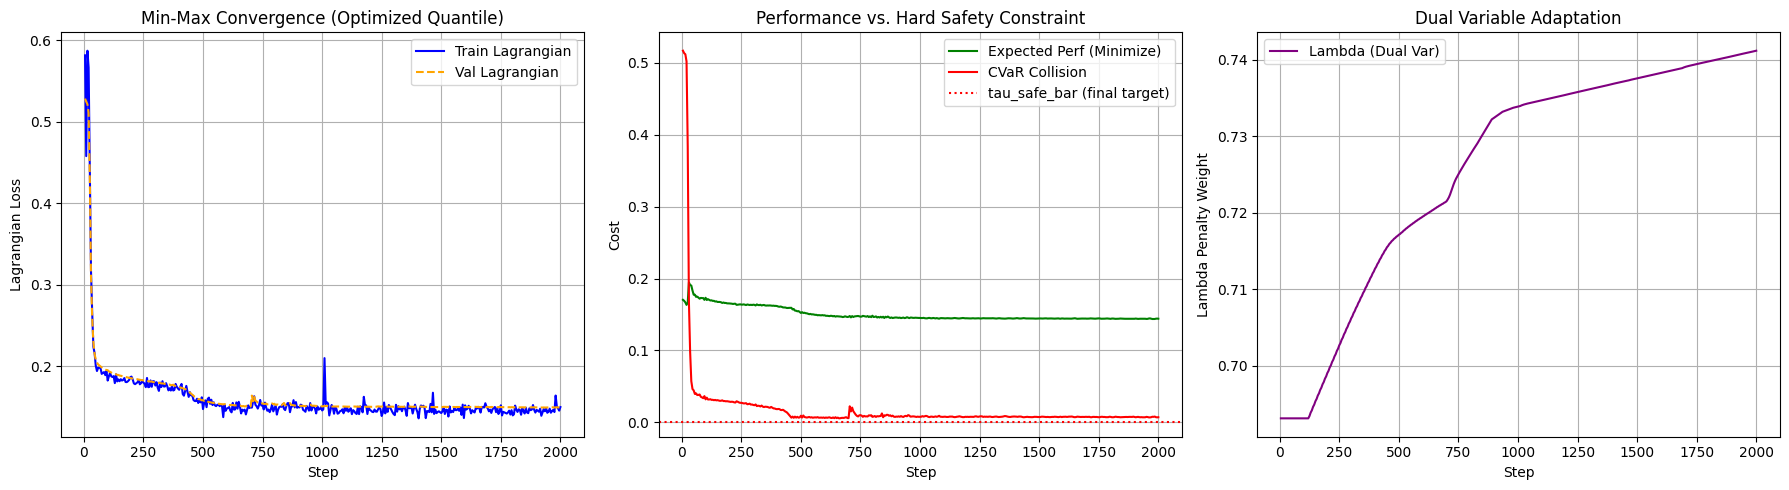

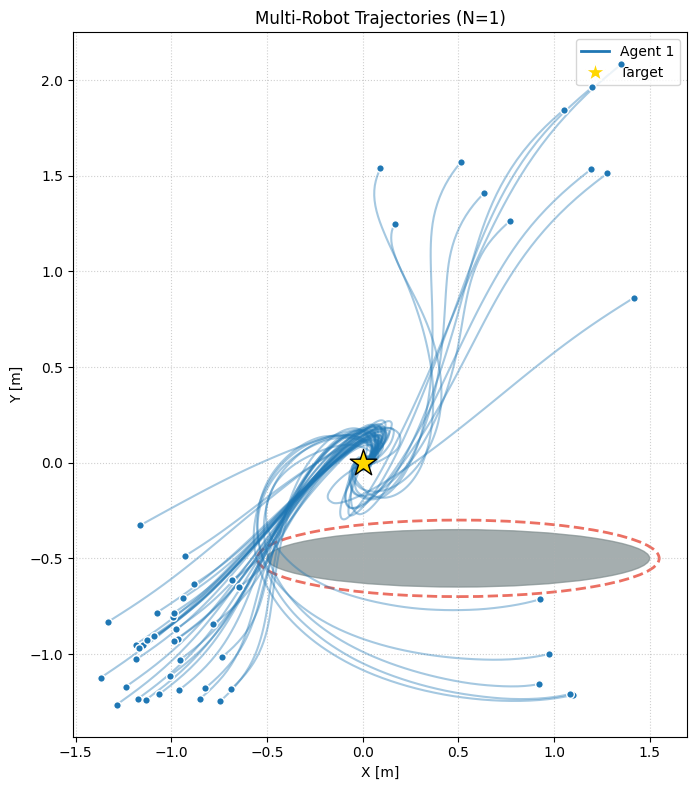

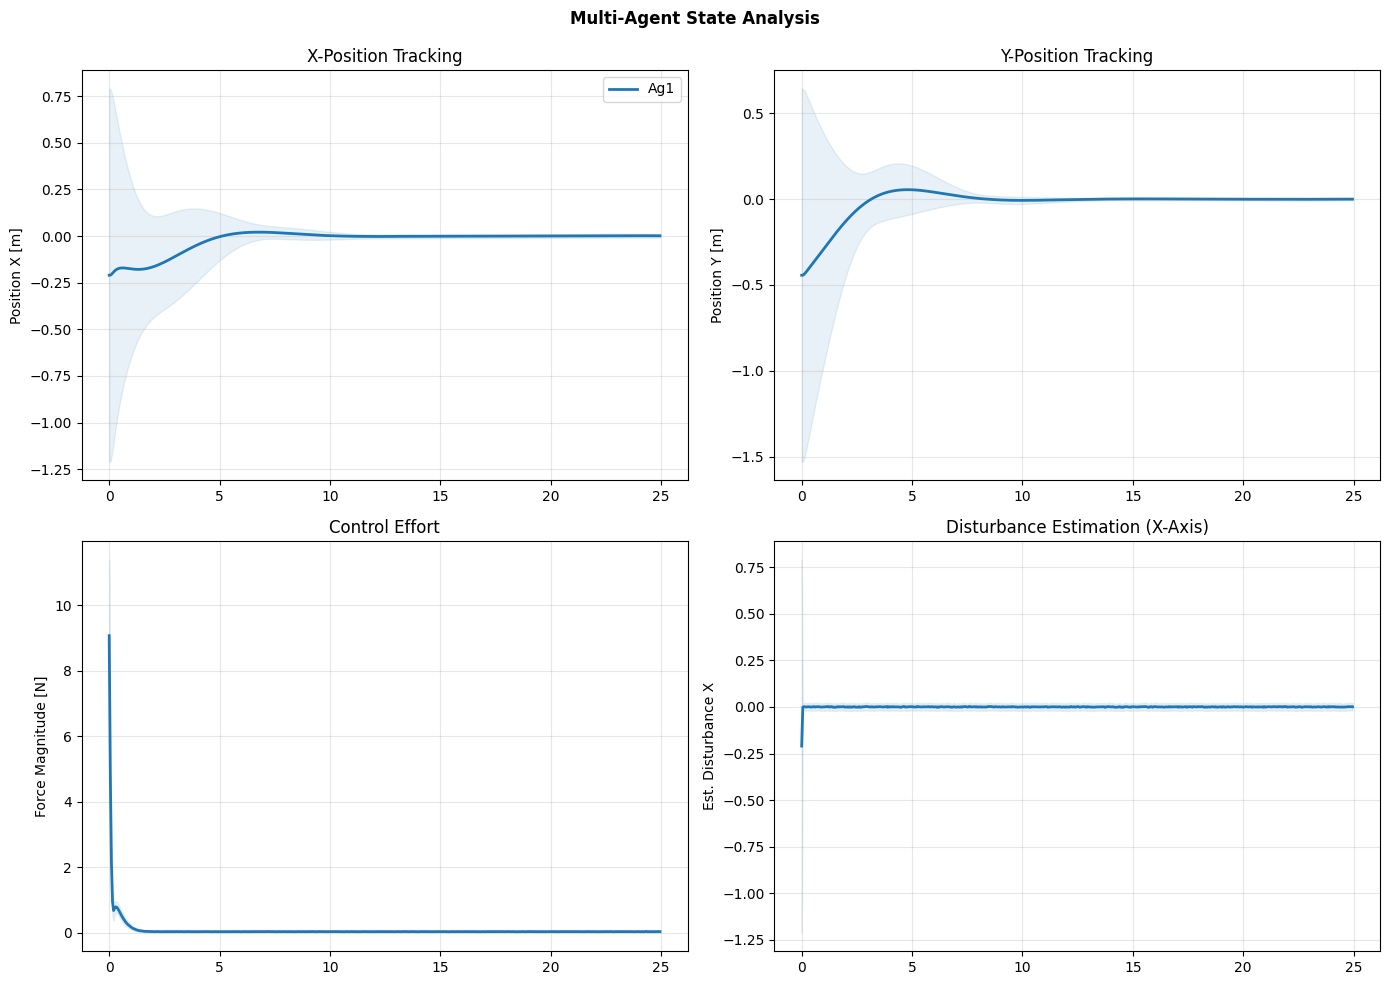

In [9]:
if len(val_lagrangians) == 0:
    raise RuntimeError("No logged validation points found. Run the optimized quantile training cell first.")

steps = range(log_interval, log_interval * (len(val_lagrangians) + 1), log_interval)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(steps, train_lagrangians, label="Train Lagrangian", color="blue")
ax1.plot(steps, val_lagrangians, label="Val Lagrangian", color="orange", linestyle="--")
ax1.set_xlabel("Step")
ax1.set_ylabel("Lagrangian Loss")
ax1.set_title("Min-Max Convergence (Optimized Quantile)")
ax1.legend()
ax1.grid(True)

ax2.plot(steps, val_perfs, label="Expected Perf (Minimize)", color="green")
ax2.plot(steps, val_cvars, label="CVaR Collision", color="red")
ax2.axhline(y=tau_safe_bar, color="red", linestyle=":", label="tau_safe_bar (final target)")
ax2.set_xlabel("Step")
ax2.set_ylabel("Cost")
ax2.set_title("Performance vs. Hard Safety Constraint")
ax2.legend()
ax2.grid(True)

ax3.plot(steps, val_lambdas, label="Lambda (Dual Var)", color="purple")
ax3.set_xlabel("Step")
ax3.set_ylabel("Lambda Penalty Weight")
ax3.set_title("Dual Variable Adaptation")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

if last_traj_x_val is None:
    raise RuntimeError("Validation trajectories were not stored. Re-run the training cell.")

plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe=obs_radii_safe,
    dt=dt,
)

## Best-checkpoint test evaluation

Load the best saved Lagrangian model and evaluate on a fresh GMM test batch.

Missing keys while loading: ['x', 'init_x']
=== Optimized quantile-constrained model test ===
Checkpoint                     : ren_lagrangian_optimized_checkpoint.pt
Target alpha_true              : 0.050000
Target tau_safe_bar            : 0.000100
Expected performance E[cx+cu]  : 0.143282
Expected collision  E[coll]    : 0.000637


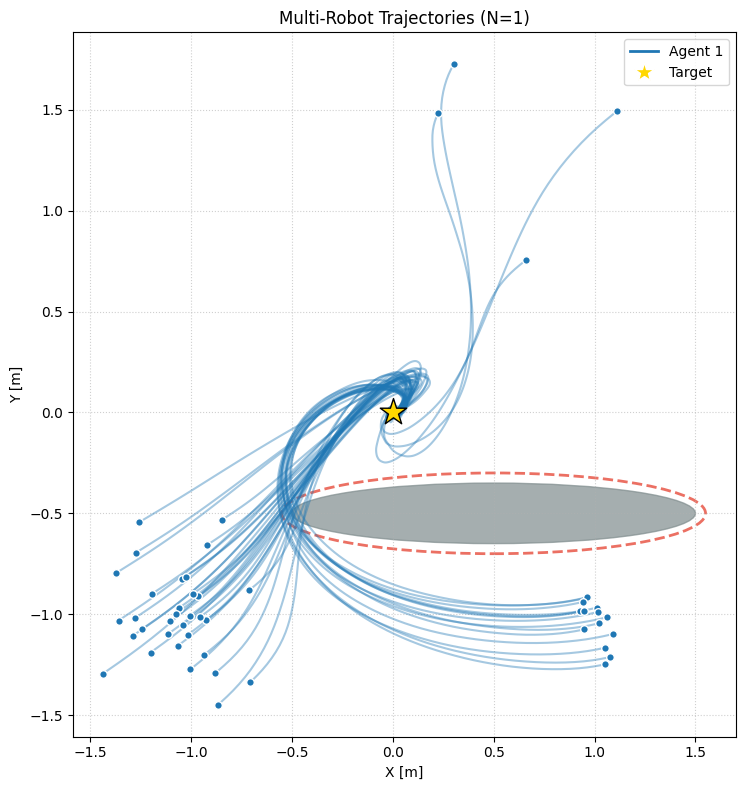

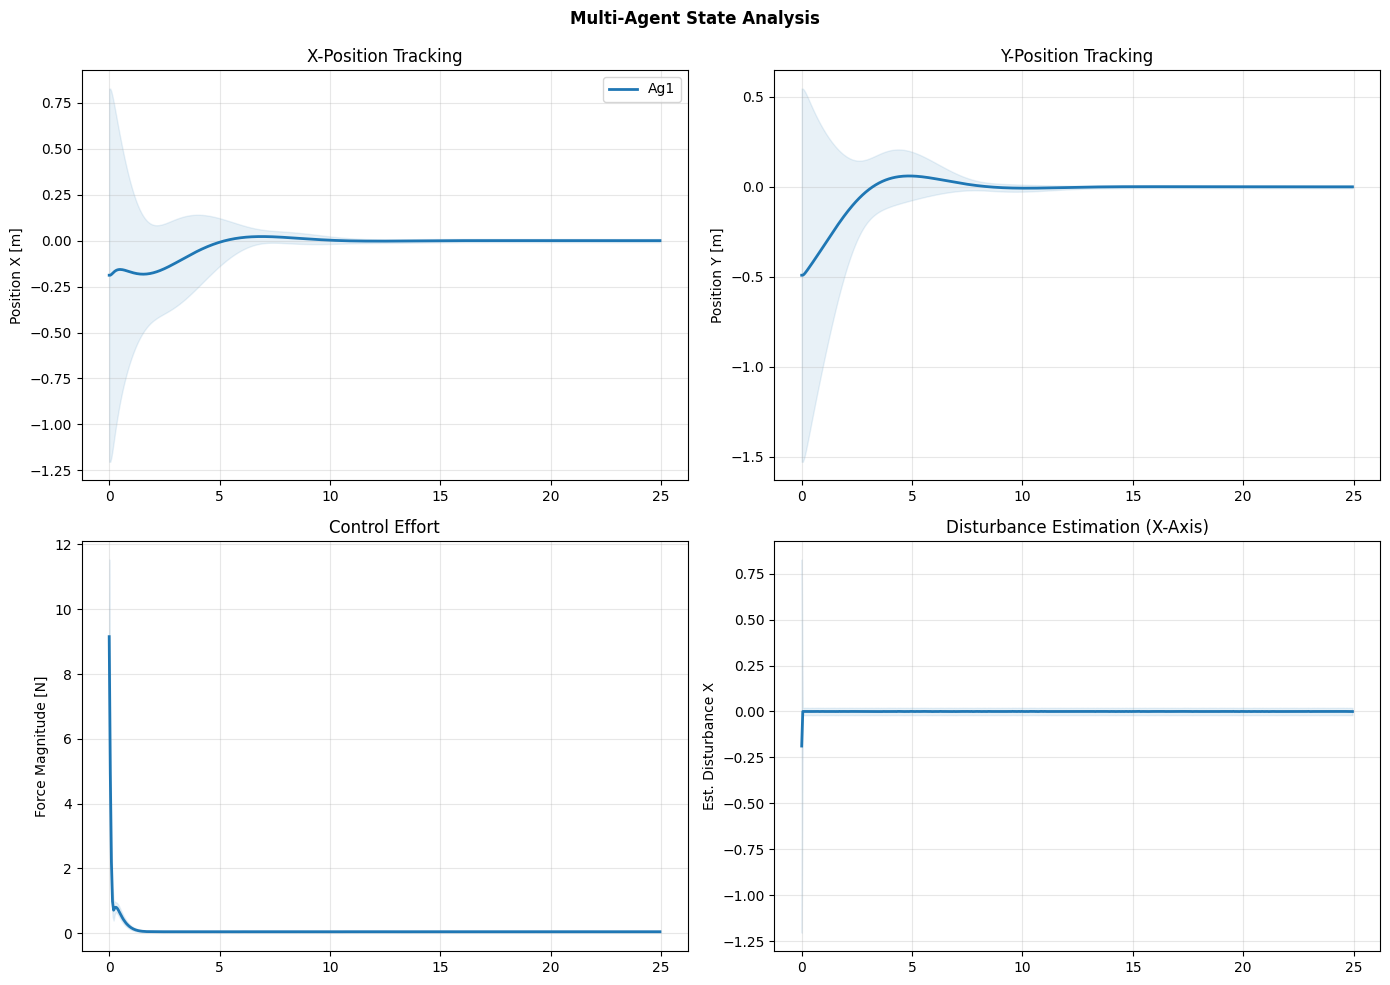

In [10]:
# Evaluate the optimized quantile-constrained checkpoint
ren_test = ContractiveREN(
    dim_in=state_dim * n_agents,
    dim_out=input_dim * n_agents,
    dim_internal=dim_internal,
    dim_nl=dim_nl,
    initialization_std=initialization_std,
).to(device)

pb_test = PBClosedLoop(ren_test, f_sim, f_nom).to(device)

ckpt = torch.load(checkpoint_path, map_location=device)
ren_state = ckpt["ren_state"] if "ren_state" in ckpt else ckpt

transient_keys = {"x", "init_x"}
ren_state = {k: v for k, v in ren_state.items() if k not in transient_keys}
load_result = ren_test.load_state_dict(ren_state, strict=False)

if len(load_result.unexpected_keys) > 0:
    print("Unexpected keys while loading:", load_result.unexpected_keys)
if len(load_result.missing_keys) > 0:
    print("Missing keys while loading:", load_result.missing_keys)

pb_test.eval()

test_w = generate_random_batch(
    batch_size=num_test_samples,
    horizon=horizon,
    n_agents=n_agents,
    x0_centers=x0_centers,
    x0_stds=x0_stds,
    x0_probs=x0_probs,
    noise_std=noise_std,
    device=device,
)

with torch.no_grad():
    traj_x_test, traj_u_test, traj_w_hat_test = pb_test.run(test_w)
    metric_eval = PBLoss(
        x_target, Q, R, lambda_obs, obs_centers,
        obs_radii_safe=obs_radii_safe,
        n_agents=n_agents,
        track_mode=track_mode,
        coll_mode=coll_mode,
    ).to(device)
    _, cost_x_test, cost_u_test, cost_coll_test = metric_eval(traj_x_test, traj_u_test)

    test_perf = cost_x_test.mean() + cost_u_test.mean()
    test_coll = cost_coll_test.mean()

print("=== Optimized quantile-constrained model test ===")
print(f"Checkpoint                     : {checkpoint_path}")
print(f"Target alpha_true              : {alpha_true:.6f}")
print(f"Target tau_safe_bar            : {tau_safe_bar:.6f}")
print(f"Expected performance E[cx+cu]  : {test_perf.item():.6f}")
print(f"Expected collision  E[coll]    : {test_coll.item():.6f}")

plot_pb_trajectories(
    traj_x=traj_x_test.detach().cpu(),
    traj_u=traj_u_test.detach().cpu(),
    traj_w_hat=traj_w_hat_test.detach().cpu(),
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe=obs_radii_safe,
    dt=dt,
)

# Expected-performance training with expected-collision constraint

This block trains a separate model with objective:
- Minimize expected performance cost `E[c_x + c_u]`
- Subject to expected collision cost `E[c_coll] <= tau_safe_bar`

using a primal-dual Lagrangian update.

In [11]:
# Reproducibility seed for expected-constraint model block
seed_expected_model = 1234

torch.manual_seed(seed_expected_model)
np.random.seed(seed_expected_model)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_expected_model)

print(f"Expected-constraint model seed set to {seed_expected_model}")

Expected-constraint model seed set to 1234


In [12]:
# Hyperparameters for expected-collision constrained optimized run
num_training_steps_exp = num_training_steps
log_interval_exp = log_interval
batch_size_exp = batch_size

lr_primal_exp = lr_primal
lr_dual_exp = lr_dual
min_lr_primal_exp = min_lr_primal
min_lr_dual_exp = min_lr_dual

max_grad_norm_exp = max_grad_norm
early_stop_patience_exp = early_stop_patience
early_stop_min_delta_exp = early_stop_min_delta

print("Expected optimized run configuration:")
print(f"  tau stage1 -> final: {tau_safe_bar_exp_stage1:.6f} -> {tau_safe_bar_exp_final:.6f}")
print(f"  steps: {num_training_steps_exp}, dual warmup: {dual_warmup_steps}")

Expected optimized run configuration:
  tau stage1 -> final: 0.000500 -> 0.000100
  steps: 2000, dual warmup: 120


In [13]:
# Build optimized model for expected-collision constrained training
ren_expected = ContractiveREN(
    dim_in=state_dim * n_agents,
    dim_out=input_dim * n_agents,
    dim_internal=dim_internal,
    dim_nl=dim_nl,
    initialization_std=initialization_std,
).to(device)

PB_closed_loop_sim_expected = PBClosedLoop(ren_expected, f_sim, f_nom).to(device)

metric_expected = PBLoss(
    x_target, Q, R, lambda_obs, obs_centers,
    obs_radii_safe=obs_radii_safe,
    n_agents=n_agents,
    track_mode=track_mode,
    coll_mode=coll_mode,
).to(device)

pre_lambda_expected = torch.nn.Parameter(torch.tensor(0.0, device=device))

opt_primal_exp = torch.optim.AdamW(
    PB_closed_loop_sim_expected.parameters(),
    lr=lr_primal_exp,
    betas=(0.9, 0.99),
    weight_decay=primal_weight_decay,
    amsgrad=True,
)
opt_dual_exp = torch.optim.Adam(
    [pre_lambda_expected],
    lr=lr_dual_exp,
    betas=(0.9, 0.99),
    maximize=True,
    amsgrad=True,
)

sched_primal_exp = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_primal_exp, mode="min", factor=lr_plateau_factor, patience=lr_plateau_patience,
    threshold=lr_plateau_threshold, min_lr=min_lr_primal_exp
)
sched_dual_exp = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_dual_exp, mode="min", factor=lr_plateau_factor, patience=lr_plateau_patience,
    threshold=lr_plateau_threshold, min_lr=min_lr_dual_exp
)

train_lag_exp = []
val_lag_exp = []
val_perf_exp = []
val_coll_exp = []
val_lambda_exp = []

last_traj_x_val_exp = None
last_traj_u_val_exp = None
last_traj_w_hat_val_exp = None

best_val_lag_exp = float("inf")
num_bad_val_exp = 0
stage1_steps_exp = int(stage1_fraction * num_training_steps_exp)
stage2_initialized_exp = False

fixed_val_w_exp = generate_random_batch(
    batch_size=num_val_samples,
    horizon=horizon,
    n_agents=n_agents,
    x0_centers=x0_centers,
    x0_stds=x0_stds,
    x0_probs=x0_probs,
    noise_std=noise_std,
    device=device,
 )

print(f"Starting optimized expected-constraint training on {device}...")
pbar_exp = tqdm(range(num_training_steps_exp), desc="Expected-Constraint Optimized")

for step in pbar_exp:
    is_stage1 = step < stage1_steps_exp
    tau_safe_bar_exp_current = tau_safe_bar_exp_stage1 if is_stage1 else tau_safe_bar_exp_final
    dual_step_interval = dual_step_interval_stage1 if is_stage1 else dual_step_interval_stage2

    if (not is_stage1) and (not stage2_initialized_exp):
        stage2_initialized_exp = True
        best_val_lag_exp = float("inf")
        num_bad_val_exp = 0
        print("Entering Stage 2: early stopping and checkpoint selection now use real tau target.")

    PB_closed_loop_sim_expected.train()
    opt_primal_exp.zero_grad(set_to_none=True)
    opt_dual_exp.zero_grad(set_to_none=True)

    batch_w = generate_random_batch(
        batch_size=batch_size_exp,
        horizon=horizon,
        n_agents=n_agents,
        x0_centers=x0_centers,
        x0_stds=x0_stds,
        x0_probs=x0_probs,
        noise_std=noise_std,
        device=device,
    )

    traj_x_train, traj_u_train, _ = PB_closed_loop_sim_expected.run(batch_w)
    _, cost_x_train, cost_u_train, cost_coll_train = metric_expected(traj_x_train, traj_u_train)

    expected_perf_train = cost_x_train.mean() + cost_u_train.mean()
    expected_coll_train = cost_coll_train.mean()
    lambda_dual_train = torch.nn.functional.softplus(pre_lambda_expected)
    lagrangian_train = expected_perf_train + lambda_dual_train * (expected_coll_train - tau_safe_bar_exp_current)

    lagrangian_train.backward()
    torch.nn.utils.clip_grad_norm_(PB_closed_loop_sim_expected.parameters(), max_grad_norm_exp)
    opt_primal_exp.step()

    should_update_dual = (step >= dual_warmup_steps) and ((step + 1) % dual_step_interval == 0)
    if should_update_dual:
        torch.nn.utils.clip_grad_norm_([pre_lambda_expected], 1.0)
        opt_dual_exp.step()
        with torch.no_grad():
            pre_lambda_expected.clamp_(-8.0, 8.0)

    if (step + 1) % log_interval_exp == 0:
        PB_closed_loop_sim_expected.eval()
        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_expected.run(fixed_val_w_exp)
            _, cost_x_val, cost_u_val, cost_coll_val = metric_expected(traj_x_val, traj_u_val)

            expected_perf_val = cost_x_val.mean() + cost_u_val.mean()
            expected_coll_val = cost_coll_val.mean()
            lambda_dual_val = torch.nn.functional.softplus(pre_lambda_expected)
            lagrangian_val = expected_perf_val + lambda_dual_val * (expected_coll_val - tau_safe_bar_exp_current)

        last_traj_x_val_exp = traj_x_val.detach().cpu()
        last_traj_u_val_exp = traj_u_val.detach().cpu()
        last_traj_w_hat_val_exp = traj_w_hat_val.detach().cpu()

        lag_train_item = lagrangian_train.item()
        lag_val_item = lagrangian_val.item()
        perf_val_item = expected_perf_val.item()
        coll_val_item = expected_coll_val.item()
        lambda_val_item = lambda_dual_val.item()
        viol_val_item = coll_val_item - tau_safe_bar_exp_current

        train_lag_exp.append(lag_train_item)
        val_lag_exp.append(lag_val_item)
        val_perf_exp.append(perf_val_item)
        val_coll_exp.append(coll_val_item)
        val_lambda_exp.append(lambda_val_item)

        if not is_stage1:
            improved = (best_val_lag_exp - lag_val_item) > early_stop_min_delta_exp
            if improved:
                best_val_lag_exp = lag_val_item
                num_bad_val_exp = 0
                torch.save(
                    {
                        "ren_state": ren_expected.state_dict(),
                        "opt_primal_state": opt_primal_exp.state_dict(),
                        "opt_dual_state": opt_dual_exp.state_dict(),
                        "pre_lambda": pre_lambda_expected.item(),
                        "step": step,
                        "val_lagrangian": best_val_lag_exp,
                        "val_perf": perf_val_item,
                        "val_expected_collision": coll_val_item,
                        "val_violation": viol_val_item,
                        "constraint": tau_safe_bar_exp_current,
                    },
                    checkpoint_path_exp,
                )
            else:
                num_bad_val_exp += 1

            # Metric-reactive LR tuning in Stage 2
            sched_primal_exp.step(lag_val_item)
            sched_dual_exp.step(max(viol_val_item, 0.0))

        bad_display_exp = "S1" if is_stage1 else f"{num_bad_val_exp}/{early_stop_patience_exp}"
        pbar_exp.set_postfix({
            "stage": "S1" if is_stage1 else "S2",
            "Val Perf": f"{perf_val_item:.3f}",
            "Val E[Coll]": f"{coll_val_item:.4f}",
            "Viol": f"{viol_val_item:.4f}",
            "Lambda": f"{lambda_val_item:.3f}",
            "lr_p": f"{opt_primal_exp.param_groups[0]['lr']:.2e}",
            "lr_d": f"{opt_dual_exp.param_groups[0]['lr']:.2e}",
            "Bad": bad_display_exp,
        })

        if (not is_stage1) and (num_bad_val_exp >= early_stop_patience_exp):
            print(
                f"Early stopping at step {step + 1}: no validation improvement > "
                f"{early_stop_min_delta_exp} for {early_stop_patience_exp} checks (Stage 2 only)."
            )
            break

pbar_exp.close()

print(f"Training complete (expected-collision constrained). Best val lagrangian (Stage 2): {best_val_lag_exp:.6f}")
print(f"Best checkpoint saved to: {checkpoint_path_exp}")
print(f"Final-stage tau target: {tau_safe_bar_exp_final:.6f}")

Starting optimized expected-constraint training on cpu...


Expected-Constraint Optimized:  35%|███▌      | 700/2000 [9:33:14<1:43:41,  4.79s/it, stage=S1, Val Perf=0.138, Val E[Coll]=0.0150, Viol=0.0145, Lambda=0.737, lr_p=1.00e-03, lr_d=3.00e-04, Bad=S1]   

Entering Stage 2: early stopping and checkpoint selection now use real tau target.


Expected-Constraint Optimized: 100%|██████████| 2000/2000 [12:08:32<00:00, 21.86s/it, stage=S2, Val Perf=0.121, Val E[Coll]=0.0103, Viol=0.0102, Lambda=0.788, lr_p=1.00e-03, lr_d=5.00e-05, Bad=19/50]   

Training complete (expected-collision constrained). Best val lagrangian (Stage 2): 0.129081
Best checkpoint saved to: ren_expected_constraint_optimized_checkpoint.pt
Final-stage tau target: 0.000100


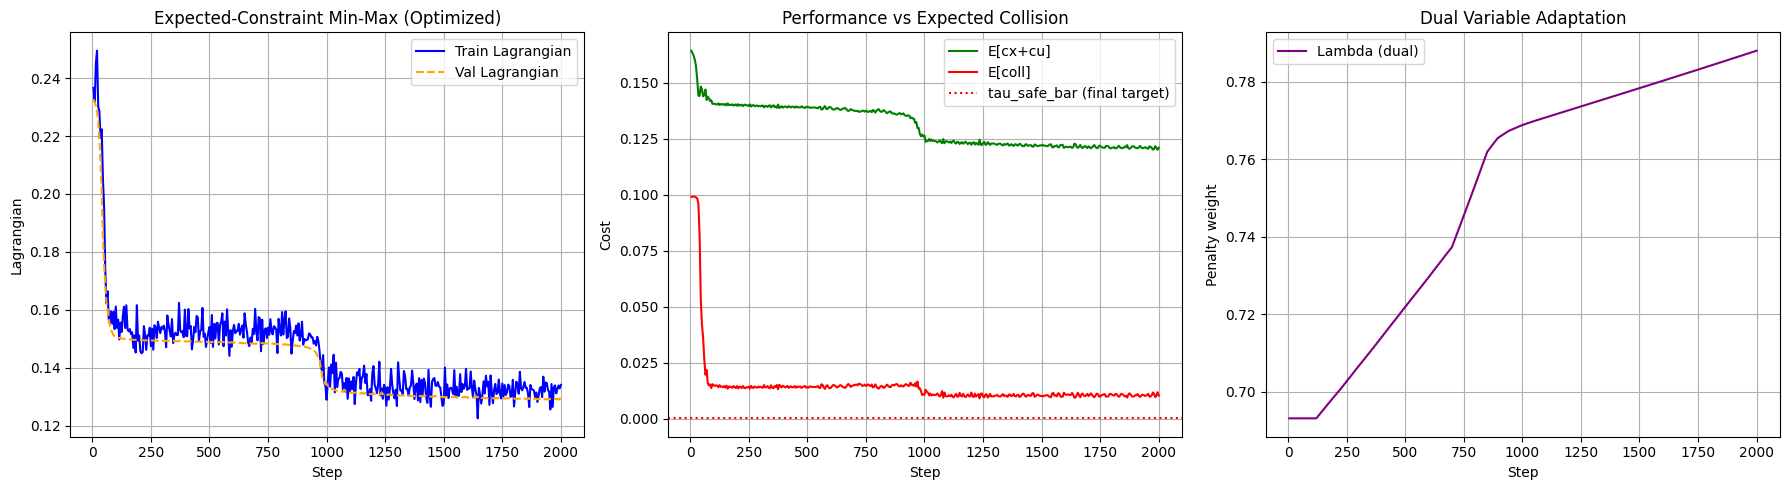

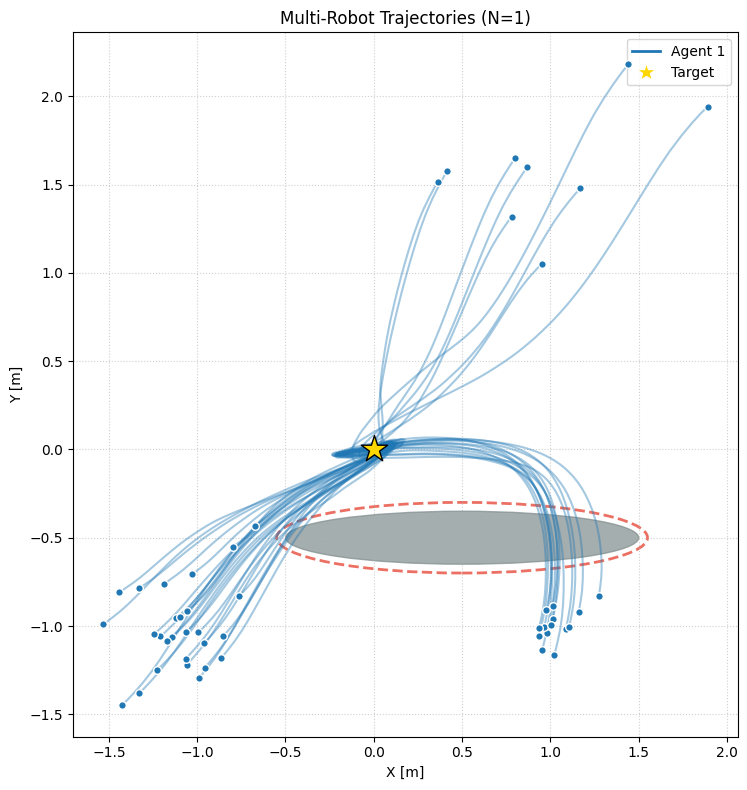

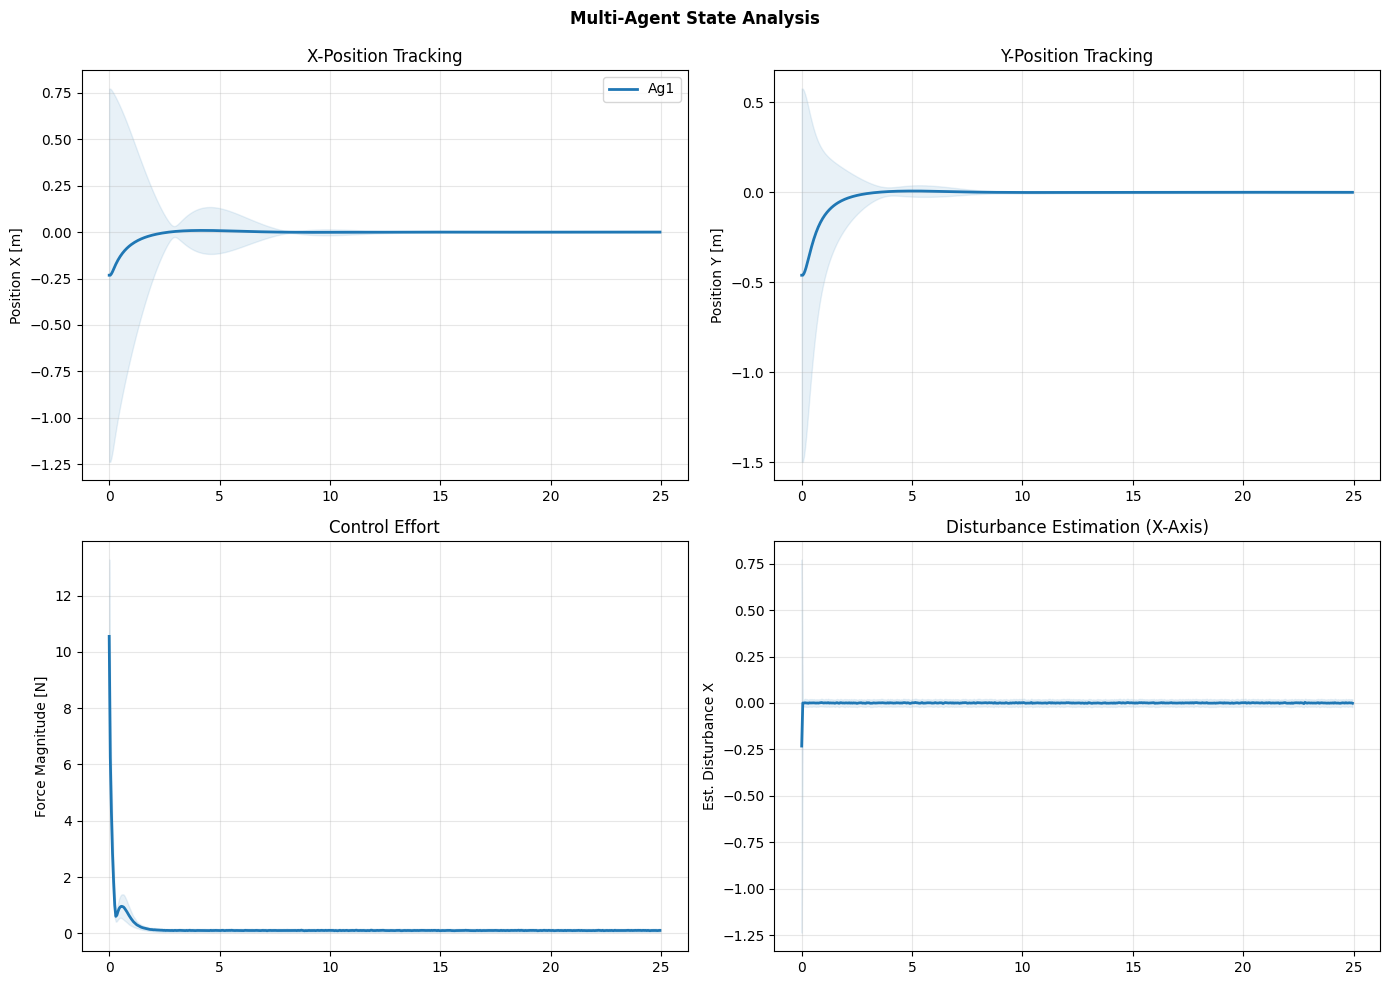

In [14]:
if len(val_lag_exp) == 0:
    raise RuntimeError("No logged points for expected-collision constrained training. Run optimized expected training first.")

steps_exp = range(log_interval_exp, log_interval_exp * (len(val_lag_exp) + 1), log_interval_exp)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(steps_exp, train_lag_exp, label="Train Lagrangian", color="blue")
ax1.plot(steps_exp, val_lag_exp, label="Val Lagrangian", color="orange", linestyle="--")
ax1.set_xlabel("Step")
ax1.set_ylabel("Lagrangian")
ax1.set_title("Expected-Constraint Min-Max (Optimized)")
ax1.legend()
ax1.grid(True)

ax2.plot(steps_exp, val_perf_exp, label="E[cx+cu]", color="green")
ax2.plot(steps_exp, val_coll_exp, label="E[coll]", color="red")
ax2.axhline(y=tau_safe_bar_exp_final, color="red", linestyle=":", label="tau_safe_bar (final target)")
ax2.set_xlabel("Step")
ax2.set_ylabel("Cost")
ax2.set_title("Performance vs Expected Collision")
ax2.legend()
ax2.grid(True)

ax3.plot(steps_exp, val_lambda_exp, label="Lambda (dual)", color="purple")
ax3.set_xlabel("Step")
ax3.set_ylabel("Penalty weight")
ax3.set_title("Dual Variable Adaptation")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

if last_traj_x_val_exp is not None:
    plot_pb_trajectories(
        traj_x=last_traj_x_val_exp,
        traj_u=last_traj_u_val_exp,
        traj_w_hat=last_traj_w_hat_val_exp,
        x_target=x_target,
        obs_centers=obs_centers,
        obs_radii=obs_radii,
        obs_radii_safe=obs_radii_safe,
        dt=dt,
    )

## Best-checkpoint test evaluation (expected-collision constraint)

Load the best saved expected-constraint model and evaluate on a fresh GMM test batch with the same shared constraint threshold.

Missing keys while loading: ['x', 'init_x']
=== Optimized expected-constraint model test ===
Checkpoint                     : ren_expected_constraint_optimized_checkpoint.pt
Target tau_safe_bar            : 0.000100
Expected performance E[cx+cu]  : 0.122185
Expected collision  E[coll]    : 0.012838


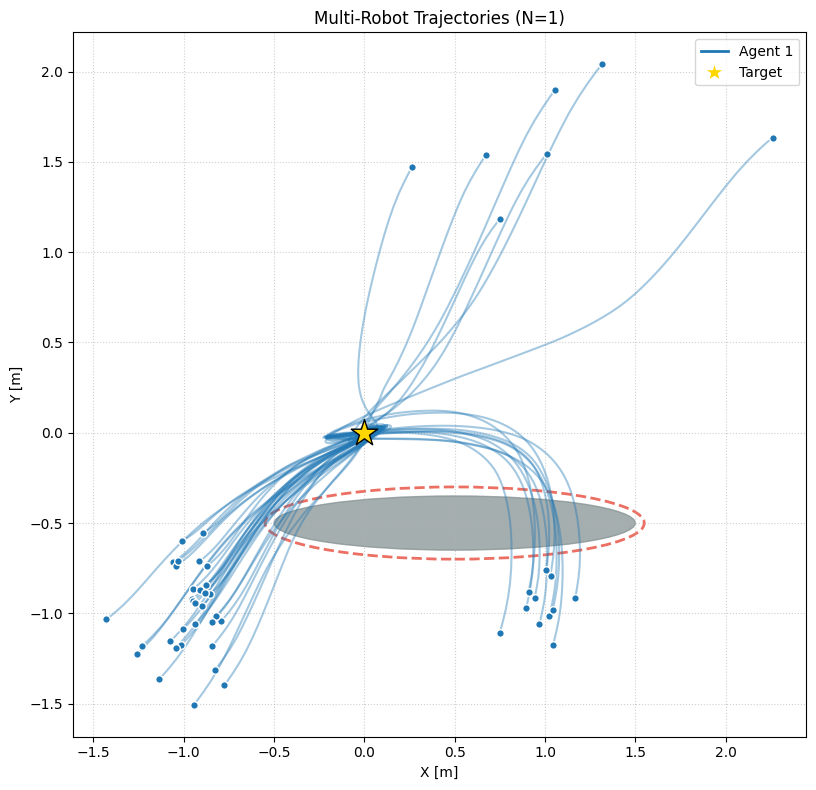

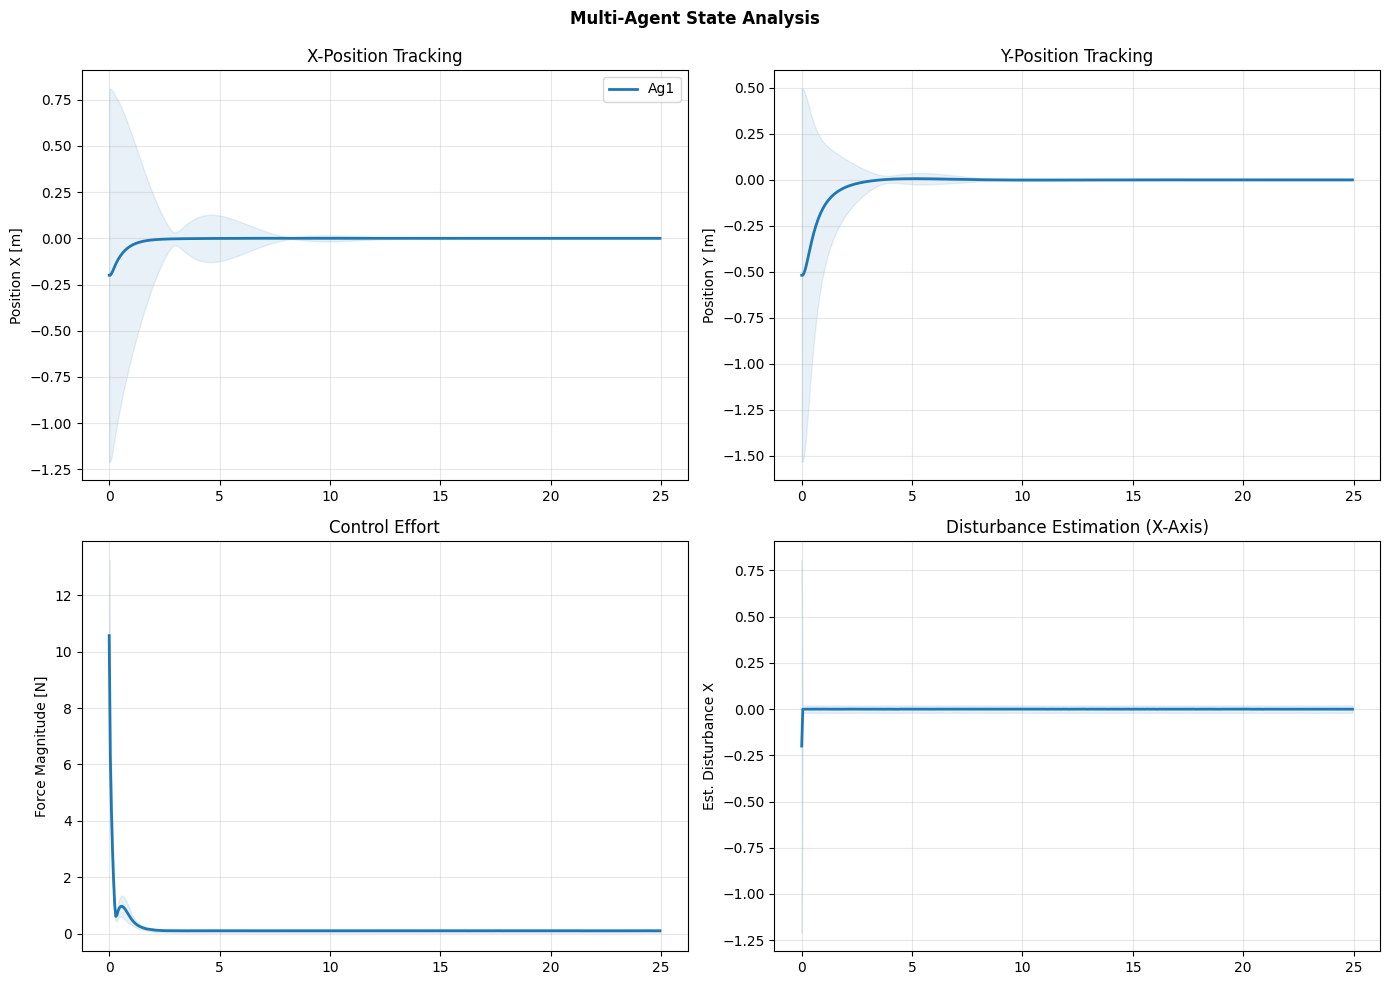

In [15]:
# Evaluate the optimized expected-constraint checkpoint
ren_test_exp = ContractiveREN(
    dim_in=state_dim * n_agents,
    dim_out=input_dim * n_agents,
    dim_internal=dim_internal,
    dim_nl=dim_nl,
    initialization_std=initialization_std,
).to(device)

pb_test_exp = PBClosedLoop(ren_test_exp, f_sim, f_nom).to(device)

ckpt_exp = torch.load(checkpoint_path_exp, map_location=device)
ren_state_exp = ckpt_exp["ren_state"] if "ren_state" in ckpt_exp else ckpt_exp
transient_keys_exp = {"x", "init_x"}
ren_state_exp = {k: v for k, v in ren_state_exp.items() if k not in transient_keys_exp}
load_result_exp = ren_test_exp.load_state_dict(ren_state_exp, strict=False)

if len(load_result_exp.unexpected_keys) > 0:
    print("Unexpected keys while loading:", load_result_exp.unexpected_keys)
if len(load_result_exp.missing_keys) > 0:
    print("Missing keys while loading:", load_result_exp.missing_keys)

pb_test_exp.eval()

test_w_exp = generate_random_batch(
    batch_size=num_test_samples_exp,
    horizon=horizon,
    n_agents=n_agents,
    x0_centers=x0_centers,
    x0_stds=x0_stds,
    x0_probs=x0_probs,
    noise_std=noise_std,
    device=device,
)

with torch.no_grad():
    traj_x_test_exp, traj_u_test_exp, traj_w_hat_test_exp = pb_test_exp.run(test_w_exp)
    metric_expected_eval = PBLoss(
        x_target, Q, R, lambda_obs, obs_centers,
        obs_radii_safe=obs_radii_safe,
        n_agents=n_agents,
        track_mode=track_mode,
        coll_mode=coll_mode,
    ).to(device)
    _, cost_x_test_exp, cost_u_test_exp, cost_coll_test_exp = metric_expected_eval(traj_x_test_exp, traj_u_test_exp)

    test_perf_exp = cost_x_test_exp.mean() + cost_u_test_exp.mean()
    test_coll_exp = cost_coll_test_exp.mean()

print("=== Optimized expected-constraint model test ===")
print(f"Checkpoint                     : {checkpoint_path_exp}")
print(f"Target tau_safe_bar            : {tau_safe_bar_exp_final:.6f}")
print(f"Expected performance E[cx+cu]  : {test_perf_exp.item():.6f}")
print(f"Expected collision  E[coll]    : {test_coll_exp.item():.6f}")

plot_pb_trajectories(
    traj_x=traj_x_test_exp.detach().cpu(),
    traj_u=traj_u_test_exp.detach().cpu(),
    traj_w_hat=traj_w_hat_test_exp.detach().cpu(),
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe=obs_radii_safe,
    dt=dt,
)